Zertifikatstudium: geoDataScience
gds050-01a: Ausgewählte Aspekte des Geoinformationswesens (S) (060884)
WiSe 25/26

Topic: Smart SH Emergency

Author: Justin Lingg-Lahaam
27.02.2026

# UG2: Transfer and Calibration Notebook: Model transfer, Calibration and Evaluation

This notebook transfers the U-Net-like CNN pipeline from UG1 to UG2 and focuses on robust evaluation and calibration of the model predictions. The workflow supports fine-tuning for the UG1-trained model on UG2 data*, UG2 application (inference) to generate a patch-wise tile prediction and generate a contineous water-depth-map and a Calibration for UG2 to reduce systematic bias between the AI-prediction and hydrodynamic reference results.

The notebook provides a considolated toolbox for raster alignment (reproject/resample), consistent making of valid pixels and a unified set of metrics covering:
-Regression (RMSE, MAE, Bias, Pearson/Spearman-correlation)
-binary flood (Precicion, Recall, F1, IoU at configurable thresholds)
-spatial impact measures (flooded area in m2 and water volume in m3)

The calibration is implemented mainly via Quantil Mapping (QM) fitted on a selected calibration event (with optional linear mapping as an experiment). The Results are reported for RAW vs. CAL predictions and can be exported as tables and figures.

*Fine-tuning was used for the optional domain-specific adaptation of the U-Net model trained on UG1 to UG2 as a test. However, the maps and metrics used in the presentation of results are based on the generated prediction grids and their subsequent calibration, not on the fine-tuning step itself (because this work was initially only concerned with evaluating the original model). `But fine-tuning serves an important step for future work, developing this Model!`

**Outputs**
- `models/final_unet_model_FINETUNED_BEST.keras` (fine tuned Model)
- `ug2/pred/predicted_depth_1_80_ug2_FIXED.tif` (UG2 RAW prediction map)
- `ug2/pred/predicted_depth_1_80_ug2_CAL_QM.tif` (UG2 CAL prediction map)

In [1]:
# Python Packages and References
import os
import glob, random
import numpy as np
import tensorflow as tf
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from keras.models import load_model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from rasterio.warp import reproject, Resampling
from scipy.stats import pearsonr, spearmanr
from scipy.ndimage import binary_dilation
from rasterio.warp import Resampling
from matplotlib.colors import ListedColormap, BoundaryNorm

2026-03-13 13:04:29.776130: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#balance dataset and load trained Model

# Function:  read trainingsdata and produce mask n 
def balanced_dataset(X_files, y_files, water_ratio=0.5):
    X_list, y_list = [], []
    for xf, yf in zip(X_files, y_files):
        X = np.load(xf)
        y = np.load(yf)

        if np.max(y) > 0: 
            X_list.append(X)
            y_list.append(y)
        else:
            if np.random.rand() < (1 - water_ratio):
                X_list.append(X)
                y_list.append(y)

    return np.array(X_list), np.array(y_list)


# load trainingsdata
X_files = sorted(glob.glob("train_patches/X_*.npy"))
y_files = sorted(glob.glob("train_patches/y_*.npy"))

X, y = balanced_dataset(X_files, y_files, water_ratio=0.5)
print("Trainingsdata:", X.shape, y.shape)


Trainingsdata: (35129, 64, 64, 4) (35129, 64, 64)


In [3]:
# read Input-raster 


#Wfunctiom: read Input-raster
def read_raster(path):
    with rasterio.open(path) as src:
        return src.read(1), src.profile

dem, profile = read_raster("input/DEM.tif")
rain, _ = read_raster("simulation/pos_synth_1_20_infil.tif")
mann, _ = read_raster("input/mkoeff_UG.tif")
infil = 2.78e-6 * np.ones_like(dem, dtype="float32")

In [4]:

# Fine-Tuning (Not relevant for this work, but an important approach for future improvements to the model. Therefore, it will remain in place for now, but is not relevant for the evaluation of the pure AI model vs. SIMWE.)
# - Base-Modell:  models/final_unet_model_1_80.keras
# - Fine-tuned:   models/final_unet_model_1_80_FINETUNED.keras

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

BASE_PATH = os.path.join(MODEL_DIR, "final_unet_model_1_80.keras") #trained model from notebook 02_train_ug1
if not os.path.exists(BASE_PATH):
    raise FileNotFoundError(f"base-model not found: {BASE_PATH}. first create or save the model or adjust the Base-path.")

FT_BEST_PATH = os.path.join(MODEL_DIR, "final_unet_model_1_80_FINETUNED_BEST.keras")
NORM_PATH = os.path.join(MODEL_DIR, "norm_params_u1.npz")

# select data source (Patches)
PATCH_DIR = os.environ.get("PATCH_DIR", "")  # z.B. "train_patches_ug2" (oder leer lassen)
# if there are no arrays in memory: termination
USE_FILES = (("X" not in globals()) or ("y" not in globals()))
if USE_FILES:
    if not PATCH_DIR:
        raise ValueError("neither X/y in Kernel nor PATCH_DIR set. Set PATCH_DIR='train_patches_ug2' or load X,y.")
    X_files = sorted(glob.glob(os.path.join(PATCH_DIR, "X_*.npy")))
    y_files = sorted(glob.glob(os.path.join(PATCH_DIR, "y_*.npy")))
    if len(X_files) == 0 or len(X_files) != len(y_files):
        raise ValueError("patch files missing or X/y number does not match.")
    # Auto-infer shapes
    X0 = np.load(X_files[0])
    PATCH_SIZE = int(X0.shape[0])
    CHANNELS = int(X0.shape[-1])
    print("Patch-files found:", len(X_files), " | patch_size:", PATCH_SIZE, "channels:", CHANNELS)
else:
    PATCH_SIZE = int(X.shape[1])
    CHANNELS = int(X.shape[-1])
    print("X/y in kernel found:", X.shape, y.shape)

#Load or generate normalisation

#Function: helper to calculate normalization parameters for every channel
def _compute_norm_from_arrays(X_arr, y_arr):
    means = np.array([X_arr[..., c].mean() for c in range(X_arr.shape[-1])], dtype="float32")
    stds  = np.array([X_arr[..., c].std()  for c in range(X_arr.shape[-1])], dtype="float32")
    y_max = float(np.nanmax(y_arr))
    return means, stds, y_max

if os.path.exists(NORM_PATH):
    norm = np.load(NORM_PATH)
    means = norm["means"].astype("float32")
    stds  = norm["stds"].astype("float32")
    y_max = float(norm["y_max"])
    print("Normalization loaded:", NORM_PATH, "| y_max:", y_max)
else:
    if USE_FILES:
        # random sample out of Files
        samp_n = min(200, len(X_files))
        idx = np.random.default_rng(42).choice(len(X_files), size=samp_n, replace=False)
        X_s = np.stack([np.load(X_files[i]).astype("float32") for i in idx], axis=0)
        y_s = np.stack([np.load(y_files[i]).astype("float32") for i in idx], axis=0)
        means, stds, y_max = _compute_norm_from_arrays(X_s, y_s)
    else:
        means, stds, y_max = _compute_norm_from_arrays(X, y)
    np.savez(NORM_PATH, means=means, stds=stds, y_max=np.array(y_max, dtype="float32"))
    print("Normalization saved:", NORM_PATH, "| y_max:", y_max)

#Load model
model = tf.keras.models.load_model(BASE_PATH, compile=False)

# freeze BatchNorm for more stable fine-tuning
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# define Loss funtion
THR_SEG_M = 0.01 #threshold: 1 cm
thr_scaled = THR_SEG_M / float(y_max)

#function: for robust regression-loss (quadratic punishment)
def weighted_huber(y_true, y_pred, delta=0.02):
    err = y_true - y_pred
    abs_err = tf.abs(err)
    huber = tf.where(abs_err <= delta, 0.5*tf.square(err), delta*(abs_err - 0.5*delta))
    mask = tf.cast(y_true > 0.0, tf.float32)
    w = 1.0 + 9.0 * mask
    return tf.reduce_mean(w * huber)

# segmentation loss for matching: wet/dry in the reference and forecast
def dice_loss(y_true_bin, y_pred_prob, eps=1e-6):
    y_true_bin = tf.cast(y_true_bin, tf.float32)
    y_pred_prob = tf.cast(y_pred_prob, tf.float32)
    inter = tf.reduce_sum(y_true_bin * y_pred_prob)
    denom = tf.reduce_sum(y_true_bin) + tf.reduce_sum(y_pred_prob)
    return 1.0 - (2.0*inter + eps) / (denom + eps)

#function: combination 
def combined_loss(y_true, y_pred):
    ld = weighted_huber(y_true, y_pred, delta=0.02) # regression-part
    # gentle wet dice
    k = 20.0
    y_true_wet = y_true > thr_scaled #segmentation-part
    p_wet = tf.sigmoid(k * (y_pred - thr_scaled))
    lseg = dice_loss(y_true_wet, p_wet)
    # range penalty keeps predictions sane (scaled space)
    lam_range = 0.2
    lrange = tf.reduce_mean(tf.nn.relu(-y_pred) + tf.nn.relu(y_pred - 1.0))
    return ld + 0.05 * lseg + lam_range * lrange # total loss

# optimizer and compile model for fine-tuning
opt = tf.keras.optimizers.Adam(learning_rate=1e-5, clipnorm=1.0)
model.compile(optimizer=opt, loss=combined_loss)

# preparation of training data
def _norm_X(X_arr):
    Xn = (X_arr - means) / np.maximum(stds, 1e-6)
    return Xn.astype("float32")

def _scale_y(y_arr):
    return (y_arr / float(y_max)).astype("float32")

RUN_FINETUNE = False  # Set true if Fine-Tuning should be used!!!!!!

if not RUN_FINETUNE:
    print("RUN_FINETUNE=False -> Fine-tuning is skipped. Set to True to train.")
else:
    if USE_FILES:
        X_all = np.stack([np.load(f).astype("float32") for f in X_files], axis=0)
        y_all = np.stack([np.load(f).astype("float32") for f in y_files], axis=0)
    else:
        X_all, y_all = X.astype("float32"), y.astype("float32")

    X_all_n = _norm_X(X_all)
    y_all_s = _scale_y(y_all)

    X_patch_train, X_patch_val, y_patch_train, y_patch_val = train_test_split(
        X_all_n, y_all_s, test_size=0.2, random_state=42
    )

    cb = [
        ModelCheckpoint(FT_BEST_PATH, monitor="val_loss", save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ]

    history_ft = model.fit(
        X_patch_train, y_patch_train[..., None],
        validation_data=(X_patch_val, y_patch_val[..., None]),
        batch_size=16,
        epochs=15,
        verbose=1,
        callbacks=cb
    )

    print("Best fine-tuned saved", FT_BEST_PATH)


X/y in kernel found: (35129, 64, 64, 4) (35129, 64, 64)
Normalization loaded: models/norm_params_u1.npz | y_max: 40.17326736450195
RUN_FINETUNE=False -> Fine-tuning is skipped. Set to True to train.


2026-03-13 13:06:51.703306: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
# Core Functions: methodological core for the evaluation part # Calibration Quantile-Mapping

#Helperfunctions for later compare prediction and reference grids and evaluation

# Function: read data
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        prof = src.profile.copy()
        nodata = src.nodata
        transform = src.transform
    return arr, prof, nodata, transform

# function: reproject/resample data to the Grids of UG2
def align_to_ref(path, ref_profile, ref_transform, ref_crs, resampling, dst_nodata=np.nan):
    with rasterio.open(path) as src:
        src_arr = src.read(1).astype("float32")
        out = np.full((ref_profile["height"], ref_profile["width"]), dst_nodata, dtype="float32")

        reproject(
            source=src_arr,
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=resampling,
            src_nodata=src.nodata,
            dst_nodata=dst_nodata
        )
    return out

# calculate area of pa pixel out of transformation
def pixel_area_from_transform(transform):
    # transform.a = pixel width, transform.e = pixel height 
    return float(abs(transform.a * transform.e))


# Masking 

#function: creates a validity mask for comparing pred vs. ref
def valid_mask(pred, ref, pred_nodata=None, ref_nodata=None, max_depth_m=10.0):
    m = np.isfinite(pred) & np.isfinite(ref)

    if pred_nodata is not None and np.isfinite(pred_nodata):
        m &= (pred != np.float32(pred_nodata))
    if ref_nodata is not None and np.isfinite(ref_nodata):
        m &= (ref != np.float32(ref_nodata))

    m &= (pred >= 0) & (pred <= max_depth_m)
    m &= (ref  >= 0) & (ref  <= max_depth_m)
    return m

# Metrics

#function: calculating metrics of evaluation 
def regression_metrics(pred, ref):
    diff = pred - ref
    rmse = float(np.sqrt(np.mean(diff**2)))
    mae  = float(np.mean(np.abs(diff)))
    bias = float(np.mean(diff))
    pr   = float(pearsonr(pred, ref)[0]) if pred.size > 2 else np.nan
    sr   = float(spearmanr(pred, ref)[0]) if pred.size > 2 else np.nan
    return {"RMSE": rmse, "MAE": mae, "Bias": bias, "Pearson": pr, "Spearman": sr}

#functin: define classification parameters for binary matrix
def classification_metrics(pred, ref, thr=0.01):
    pred_f = pred > thr
    ref_f  = ref  > thr

    TP = int(np.sum(pred_f & ref_f))
    FP = int(np.sum(pred_f & (~ref_f)))
    FN = int(np.sum((~pred_f) & ref_f))
    TN = int(np.sum((~pred_f) & (~ref_f)))

    acc = (TP + TN) / max(TP + TN + FP + FN, 1)
    prec = TP / max(TP + FP, 1)
    rec  = TP / max(TP + FN, 1)
    f1   = (2*prec*rec) / max(prec + rec, 1e-12)
    iou  = TP / max(TP + FP + FN, 1)

    return {
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "Accuracy": float(acc),
        "Precision": float(prec),
        "Recall": float(rec),
        "F1": float(f1),
        "IoU": float(iou)
    }

# function: define spatial metrics (area and volume)
def spatial_metrics_2d(pred2d, ref2d, valid2d, pixel_area, thr=0.01):
    mm = valid2d & np.isfinite(pred2d) & np.isfinite(ref2d)
    pred_f = (pred2d > thr) & mm
    ref_f  = (ref2d  > thr) & mm

    area_pred = float(np.sum(pred_f) * pixel_area)
    area_ref  = float(np.sum(ref_f)  * pixel_area)
    area_intersection = float(np.sum(pred_f & ref_f) * pixel_area)

    vol_pred = float(np.sum(pred2d[pred_f]) * pixel_area)
    vol_ref  = float(np.sum(ref2d[ref_f])  * pixel_area)

    return {
        "Area_pred_m2": area_pred,
        "Area_ref_m2": area_ref,
        "Area_intersection_m2": area_intersection,
        "Area_diff_m2": float(area_pred - area_ref),
        "Vol_pred_m3": vol_pred,
        "Vol_ref_m3": vol_ref,
        "Vol_diff_m3": float(vol_pred - vol_ref),
    }

#  Regression on Union/Intersection (wet-only Diagnostik)

# function: adds a prefix to all dictionary keys
def _prefix(d, pref):
    return {f"{pref}{k}": v for k, v in d.items()}

# function: calculates regression mezrics on two masks (wet_union: (pred>thr) OR (ref>thr), wet_inter: (pred>thr) AND (ref>thr))
def regression_on_masks(pred2d, ref2d, valid2d, thr):
    mm = valid2d & np.isfinite(pred2d) & np.isfinite(ref2d)
    wet_p = (pred2d > thr) & mm
    wet_r = (ref2d  > thr) & mm

    union = wet_p | wet_r
    inter = wet_p & wet_r

    out = {}
    if np.any(union):
        out.update(_prefix(regression_metrics(pred2d[union].ravel(), ref2d[union].ravel()), "wet_union_"))
        out["wet_union_n"] = int(np.sum(union))
    else:
        out["wet_union_n"] = 0

    if np.any(inter):
        out.update(_prefix(regression_metrics(pred2d[inter].ravel(), ref2d[inter].ravel()), "wet_inter_"))
        out["wet_inter_n"] = int(np.sum(inter))
    else:
        out["wet_inter_n"] = 0

    return out

# Tolerant IoU (Near-Miss Spatial): Normal IoU requires exact pixel matching. This function allows small spatial deviations

#function: calculated tolerant IoU
def tolerant_iou_2d(pred2d, ref2d, valid2d, thr=0.01, r=2):
    mm = valid2d & np.isfinite(pred2d) & np.isfinite(ref2d)
    p = (pred2d > thr) & mm
    r0 = (ref2d  > thr) & mm
    s = np.ones((2*r+1, 2*r+1), dtype=bool)
    r_dil = binary_dilation(r0, structure=s)
    TP = np.sum(p & r_dil)
    FP = np.sum(p & ~r_dil)
    FN = np.sum(~p & r0)
    return float(TP / max(TP + FP + FN, 1))

#  Calibration: Quantile-Mapping (QM)

# function: Prepare quantiles so that np.interp works reliably
def _safe_interp_setup(x, y):
    x = np.asarray(x, dtype="float32")
    y = np.asarray(y, dtype="float32")
    xs, idx = np.unique(x, return_index=True)
    ys = y[idx]
    if xs.size < 2:
        xs = np.array([0.0, 1.0], dtype="float32")
        y0 = float(ys[0]) if ys.size else 0.0
        ys = np.array([y0, y0], dtype="float32")
    return xs, ys

# Function: Adjusts a quantile mapping calibrator
def fit_quantile_calibrator(pred_path, ref_path, max_depth_m=10.0, n_q=2000, ref_is_categorical=False):
    pred, pred_prof, pred_nod, pred_transform = read_raster(pred_path)

    resamp = Resampling.nearest if ref_is_categorical else Resampling.bilinear
    ref = align_to_ref(
        ref_path,
        ref_profile=pred_prof,
        ref_transform=pred_transform,
        ref_crs=pred_prof["crs"],
        resampling=resamp,
        dst_nodata=np.nan
    )

    m = valid_mask(pred, ref, pred_nod, None, max_depth_m=max_depth_m)
    if int(np.sum(m)) == 0:
        raise ValueError("No valid pixels for calibration.")

    p = pred[m].ravel()
    r = ref[m].ravel()

    qs = np.linspace(0, 1, int(n_q))
    pred_q = np.quantile(p, qs).astype("float32")
    ref_q  = np.quantile(r, qs).astype("float32")

    pred_q_u, ref_q_u = _safe_interp_setup(pred_q, ref_q)
    return {"type": "QM", "pred_q": pred_q_u, "ref_q": ref_q_u, "max_depth_m": float(max_depth_m)}

# Function: Applies the learned quantile mapping to a prediction map
def apply_quantile_calibrator(pred_map, calib):
    flat = pred_map.ravel().astype("float32")
    out = flat.copy()
    m = np.isfinite(out)
    out[m] = np.interp(out[m], calib["pred_q"], calib["ref_q"]).astype("float32")
    out = np.clip(out, 0, calib["max_depth_m"])
    return out.reshape(pred_map.shape).astype("float32")

# Function: Fits a linear mapping
def fit_linear_calibrator(pred_path, ref_path, max_depth_m=10.0, ref_is_categorical=False):
    pred, pred_prof, pred_nod, pred_transform = read_raster(pred_path)

    resamp = Resampling.nearest if ref_is_categorical else Resampling.bilinear
    ref = align_to_ref(
        ref_path,
        ref_profile=pred_prof,
        ref_transform=pred_transform,
        ref_crs=pred_prof["crs"],
        resampling=resamp,
        dst_nodata=np.nan
    )

    m = valid_mask(pred, ref, pred_nod, None, max_depth_m=max_depth_m)
    if int(np.sum(m)) == 0:
        raise ValueError("No valid pixels for calibration.")

    p = pred[m].ravel().astype("float64")
    r = ref[m].ravel().astype("float64")

    A = np.vstack([p, np.ones_like(p)]).T
    a, b = np.linalg.lstsq(A, r, rcond=None)[0]
    return {"type": "LIN", "a": float(a), "b": float(b), "max_depth_m": float(max_depth_m)}
    
# Function: Applies the learned linear mapping to a prediction map
def apply_linear_calibrator(pred_map, calib):
    out = calib["a"] * pred_map + calib["b"]
    out = np.clip(out, 0, calib["max_depth_m"])
    return out.astype("float32")


# central evaluation functio

#Function: evaluation for event UG2
def evaluate_event(pred_path, ref_path, thr=0.01, max_depth_m=10.0, ref_is_categorical=False, calibrator=None):
    pred, pred_prof, pred_nod, pred_transform = read_raster(pred_path)
    pixel_area = pixel_area_from_transform(pred_transform)

    # align ref to pred grid
    resamp = Resampling.nearest if ref_is_categorical else Resampling.bilinear
    ref = align_to_ref(
        ref_path,
        ref_profile=pred_prof,
        ref_transform=pred_transform,
        ref_crs=pred_prof["crs"],
        resampling=resamp,
        dst_nodata=np.nan
    )

    # apply calibration (post-hoc)
    method = "RAW"
    pred_used = pred
    if calibrator is not None:
        method = f"CAL_{calibrator.get('type', 'UNK')}"
        if calibrator.get("type") == "QM":
            pred_used = apply_quantile_calibrator(pred, calibrator)
        elif calibrator.get("type") == "LIN":
            pred_used = apply_linear_calibrator(pred, calibrator)
        else:
            raise ValueError(f"Unknown calibrator type: {calibrator.get('type')}")

    # mask
    m = valid_mask(pred_used, ref, pred_nod, None, max_depth_m=max_depth_m)
    n = int(np.sum(m))
    if n == 0:
        return {"n_valid": 0, "error": "No valid pixels after masking.", "method": method}

    # flattened arrays for classic regression/classification
    p = pred_used[m].ravel()
    r = ref[m].ravel()

    out = {
        "n_valid": n,
        "pred_path": pred_path,
        "ref_path": ref_path,
        "thr_m": float(thr),
        "max_depth_m": float(max_depth_m),
        "method": method,
    }

    # union/intersection wet regression
    out.update(regression_on_masks(pred_used, ref, m, thr))

    # tolerant IoU
    out["tIoU_r0"] = tolerant_iou_2d(pred_used, ref, m, thr=thr, r=0)
    out["tIoU_r1"] = tolerant_iou_2d(pred_used, ref, m, thr=thr, r=1)
    out["tIoU_r2"] = tolerant_iou_2d(pred_used, ref, m, thr=thr, r=2)
    out["tIoU_r3"] = tolerant_iou_2d(pred_used, ref, m, thr=thr, r=3)

    # classic metrics
    out.update(regression_metrics(p, r))
    out.update(classification_metrics(p, r, thr=thr))
    out.update(spatial_metrics_2d(pred_used, ref, m, pixel_area=pixel_area, thr=thr))
    return out

In [6]:
# Define UG2
events = [
    {
        "name": "UG2_1_80", # Prediction (AI)
        "pred": "ug2/pred/predicted_depth_1_80_ug2_FIXED.tif", # reference (SIMWE)
        "ref":  "input/ug2/ug2_grass/synth_water_depth_1_80_ug2" 
    }, #dict, because for future analyses, we can add more events (preciptation)
]

# fit calibration (CAL) on event
calib_event = events[0]  # z.B. UG2_1_80
cal_qm = fit_quantile_calibrator(
    calib_event["pred"], calib_event["ref"],
    max_depth_m=10.0, n_q=2000
)
# optional linear (in this work we focus on QM-Mapping):
# cal_lin = fit_linear_calibrator(calib_event["pred"], calib_event["ref"], max_depth_m=10.0)

# evaluation: RAW + CAL_QM per Event
results = []
for e in events:
    # RAW
    r_raw = evaluate_event(e["pred"], e["ref"], thr=0.01, max_depth_m=10.0)
    r_raw["event"] = e["name"]
    results.append(r_raw)

    # CAL_QM
    r_cal = evaluate_event(e["pred"], e["ref"], thr=0.01, max_depth_m=10.0, calibrator=cal_qm)
    r_cal["event"] = e["name"]
    results.append(r_cal)

df = pd.DataFrame(results)
df


,n_valid,pred_path,ref_path,thr_m,max_depth_m,method,wet_union_RMSE,wet_union_MAE,wet_union_Bias,wet_union_Pearson,...,F1,IoU,Area_pred_m2,Area_ref_m2,Area_intersection_m2,Area_diff_m2,Vol_pred_m3,Vol_ref_m3,Vol_diff_m3,event
0,3992004,ug2/pred/predicted_depth_1_80_ug2_FIXED.tif,input/ug2/ug2_grass/synth_water_depth_1_80_ug2,0.01,10.0,RAW,0.073560,0.053886,0.047444,0.148848,...,0.307519,0.181697,833839.0,180226.0,155922.0,653613.0,50841.164062,7823.348145,43017.815918,UG2_1_80
1,3992004,ug2/pred/predicted_depth_1_80_ug2_FIXED.tif,input/ug2/ug2_grass/synth_water_depth_1_80_ug2,0.01,10.0,CAL_QM,0.077528,0.038057,0.001010,0.082929,...,0.283710,0.165304,180220.0,180226.0,51131.0,-6.0,8074.394531,7823.348145,251.046387,UG2_1_80


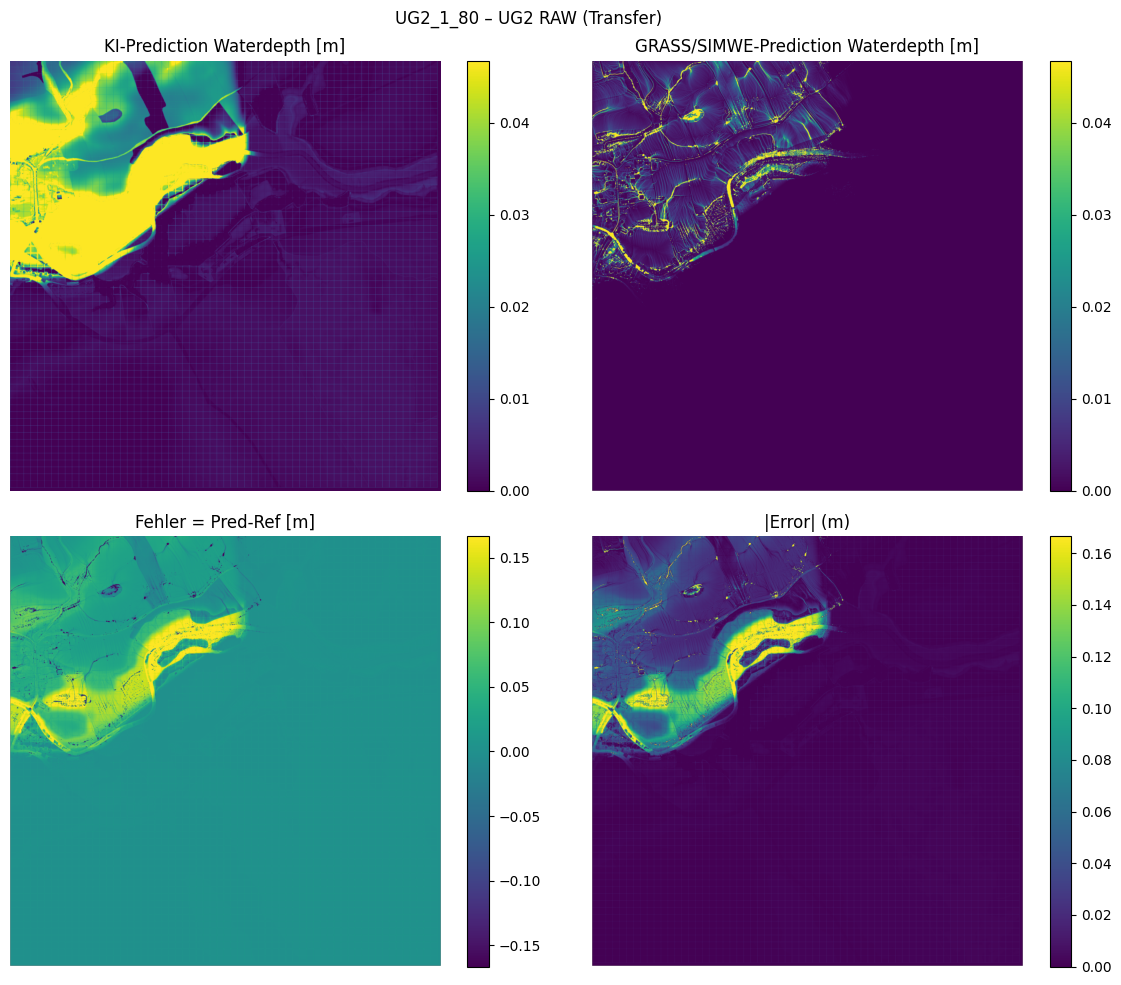

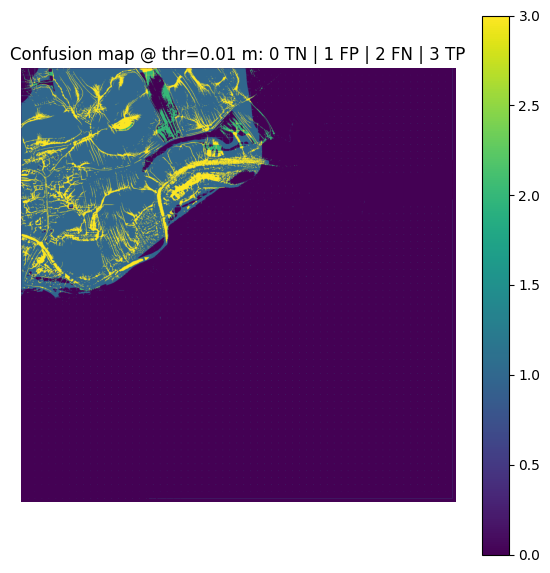

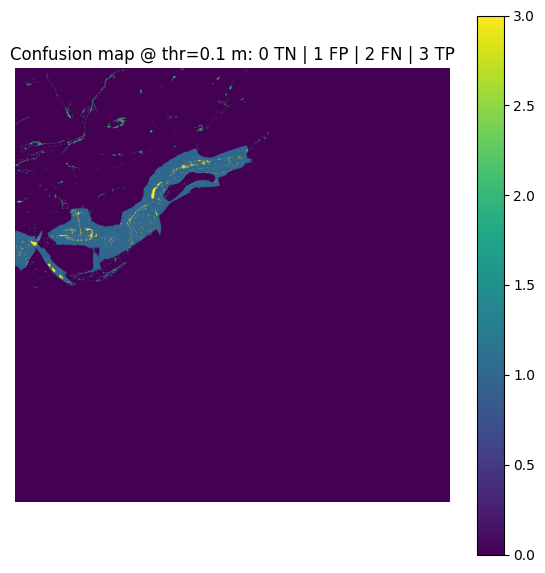

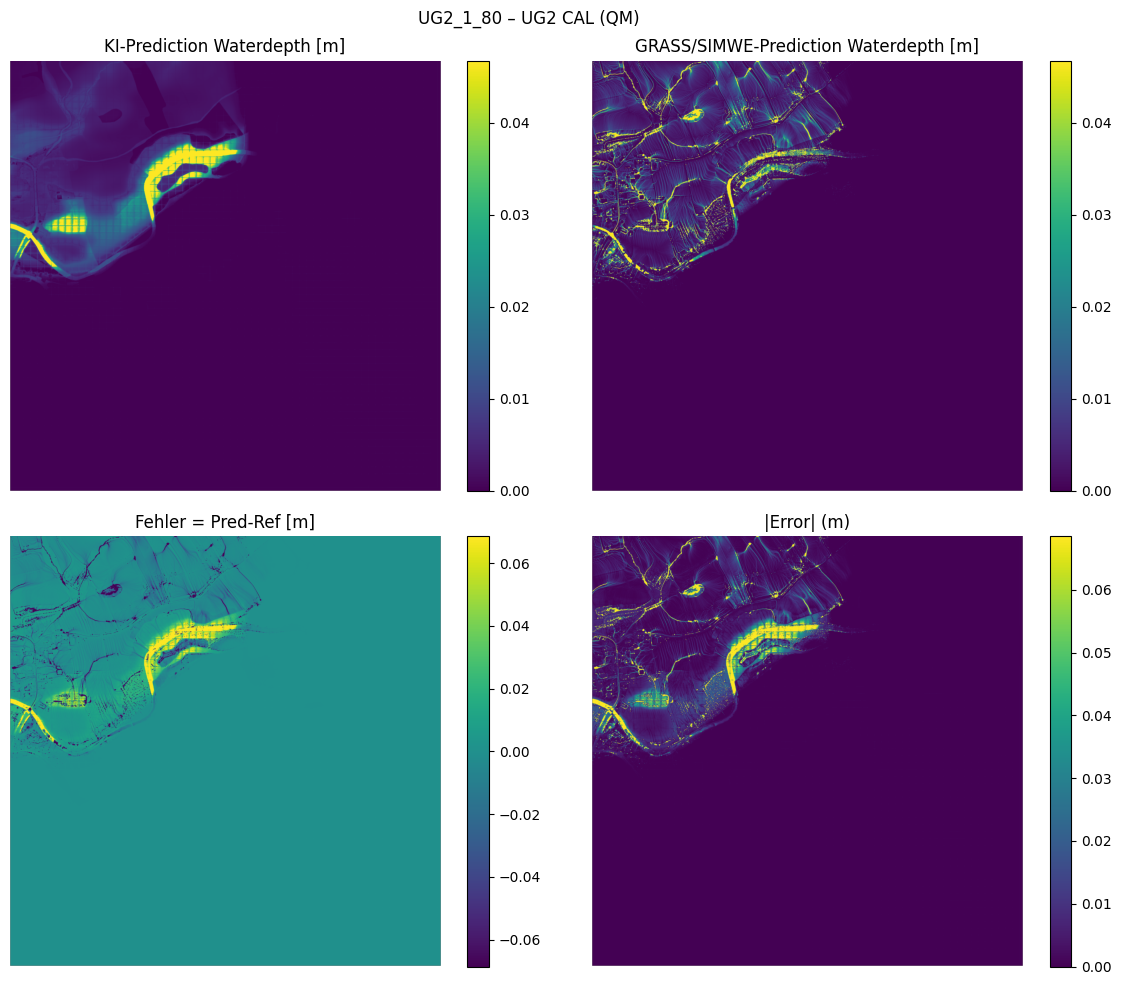

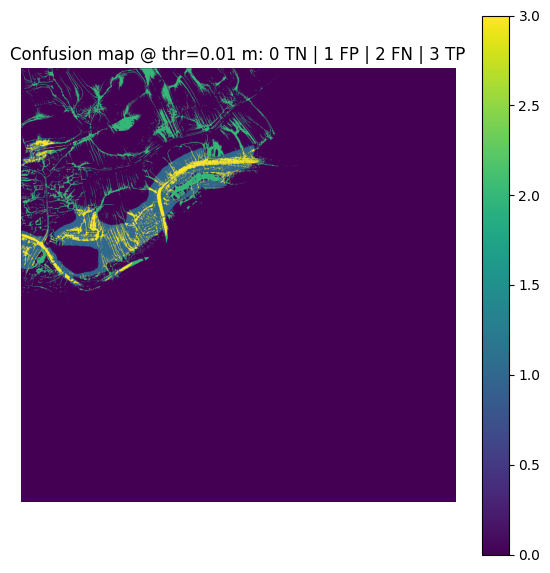

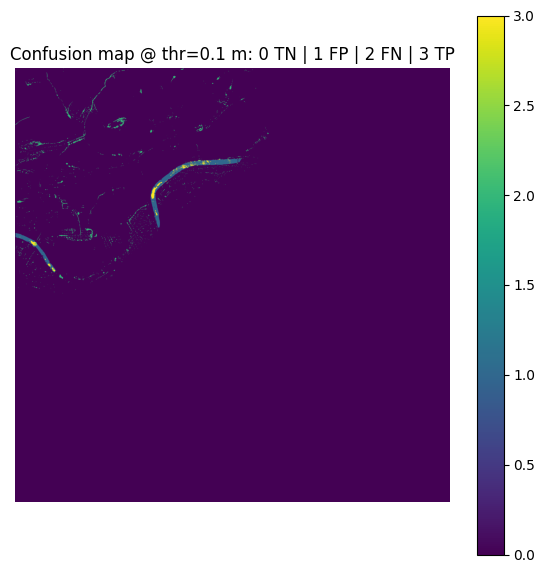

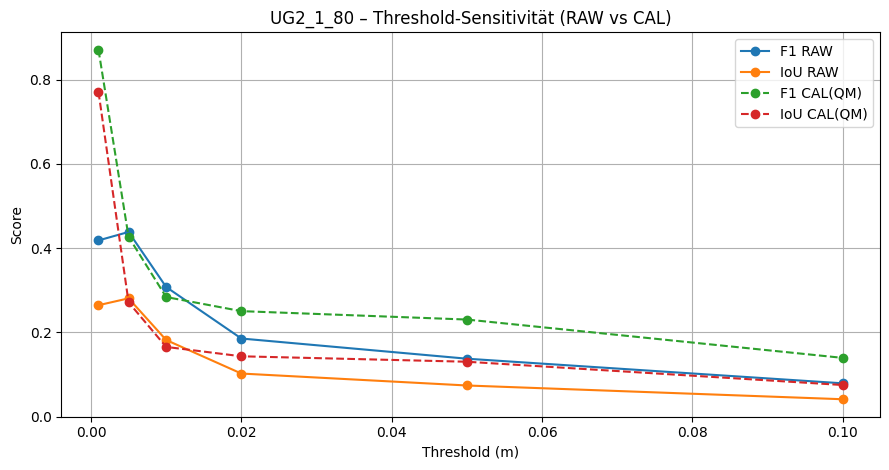


Thr | PredExt RAW | PredExt CAL | RefExt | FP RAW | FN RAW | FP CAL | FN CAL  (all m²)
-----------------------------------------------------------------------------------------
0.001 |   2898806.0 |    822217.0 | 822364.0 | 2120852.0 | 44410.0 | 106262.0 | 106409.0
0.005 |   1171715.0 |    377626.0 | 377531.0 | 832270.0 | 38086.0 | 216513.0 | 216418.0
0.010 |    833839.0 |    180220.0 | 180226.0 | 677917.0 | 24304.0 | 129089.0 | 129095.0
0.020 |    757764.0 |     91792.0 |  91785.0 | 679081.0 | 13102.0 | 68823.0 | 68816.0
0.050 |    338717.0 |     37233.0 |  37246.0 | 312905.0 | 11434.0 | 28658.0 | 28671.0
0.100 |    157509.0 |     17081.0 |  17016.0 | 150629.0 | 10136.0 | 14707.0 | 14642.0

 CAL GeoTIFF saved: ug2/pred/predicted_depth_1_80_ug2_CAL_QM.tif


In [7]:
# Demonstration and Visualisation of the results (UG2 with and without QM-CAL)

# Settings
CALIB_EVENT = "UG2_1_80" # Event
THRS = np.array([0.001,0.005,0.01,0.02,0.05,0.10], dtype="float32") #thresholds (forjustification of threshold-use)
MAX_DEPTH_M = 10.0                       
SAVE_CAL_TIF = True
CAL_TIF_OUT = "ug2/pred/predicted_depth_1_80_ug2_CAL_QM.tif"
NODATA_OUT = -9999.0

# function: helperfunction for calculating the pixel size in square metres from the raster profile
def pixel_area_from_profile(profile):
    tr = profile["transform"]
    return float(abs(tr.a * tr.e))

# function: Load and align prediction and reference
def load_pred_ref_aligned(pred_path, ref_path, ref_is_categorical=False):
    pred, pred_prof, pred_nod, pred_transform = read_raster(pred_path)
    resamp = Resampling.nearest if ref_is_categorical else Resampling.bilinear
    ref = align_to_ref(
        ref_path,
        ref_profile=pred_prof,
        ref_transform=pred_transform,
        ref_crs=pred_prof["crs"],
        resampling=resamp,
        dst_nodata=np.nan
    )
    m = valid_mask(pred, ref, pred_nod, None, max_depth_m=MAX_DEPTH_M)
    return pred, ref, m, pred_prof, pred_nod

# function: plot visualization
def show_panel(pred, ref, title, vmax):
    m = np.isfinite(pred) & np.isfinite(ref)
    err = pred - ref
    abse = np.abs(err)
    errlim = np.nanpercentile(abse[m], 99) if np.any(m) else 1.0

    fig, ax = plt.subplots(2,2, figsize=(12,10))
    im0=ax[0,0].imshow(pred, vmin=0, vmax=vmax); ax[0,0].set_title("KI-Prediction Waterdepth [m]")
    im1=ax[0,1].imshow(ref,  vmin=0, vmax=vmax); ax[0,1].set_title("GRASS/SIMWE-Prediction Waterdepth [m]")
    im2=ax[1,0].imshow(err,  vmin=-errlim, vmax=errlim); ax[1,0].set_title("Fehler = Pred-Ref [m]")
    im3=ax[1,1].imshow(abse, vmin=0, vmax=errlim); ax[1,1].set_title("|Error| (m)")
    for a in ax.ravel(): a.axis("off")
    fig.colorbar(im0, ax=ax[0,0], fraction=0.046)
    fig.colorbar(im1, ax=ax[0,1], fraction=0.046)
    fig.colorbar(im2, ax=ax[1,0], fraction=0.046)
    fig.colorbar(im3, ax=ax[1,1], fraction=0.046)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Function: confusion-matrix and visualize it 
def confusion_map(pred, ref, mask, thr):
    p = (pred >= thr) & mask
    r = (ref  >= thr) & mask
    TP = p & r
    FP = p & (~r)
    FN = (~p) & r
    TN = (~p) & (~r)
    cls = np.full(pred.shape, np.nan, dtype="float32")
    cls[TN]=0; cls[FP]=1; cls[FN]=2; cls[TP]=3
    plt.figure(figsize=(7,7))
    plt.imshow(cls, vmin=0, vmax=3)
    plt.title(f"Confusion map @ thr={thr} m: 0 TN | 1 FP | 2 FN | 3 TP")
    plt.axis("off")
    plt.colorbar()
    plt.show()

# function: define metrics
def metrics_counts(pred, ref, mask, thr):
    p = (pred >= thr) & mask
    r = (ref  >= thr) & mask
    TP = int(np.sum(p & r))
    FP = int(np.sum(p & (~r)))
    FN = int(np.sum((~p) & r))
    prec = TP / (TP + FP + 1e-9)
    rec  = TP / (TP + FN + 1e-9)
    f1   = 2*prec*rec / (prec+rec+1e-9)
    iou  = TP / (TP + FP + FN + 1e-9)
    return prec, rec, f1, iou, TP, FP, FN

# fit QM-calibration
cal_ev = [e for e in events if e["name"] == CALIB_EVENT][0]
cal_qm = fit_quantile_calibrator(cal_ev["pred"], cal_ev["ref"], max_depth_m=MAX_DEPTH_M, n_q=2000)

# visualize QM-Calibration for UG2
pred_raw, ref, m, pred_prof, pred_nod = load_pred_ref_aligned(cal_ev["pred"], cal_ev["ref"])
pred_cal = apply_quantile_calibrator(pred_raw, cal_qm)
pred_cal[~m] = np.nan

vmax_common = np.nanpercentile(ref[m], 99) if np.any(m) else 1.0

show_panel(pred_raw, ref, title=f"{CALIB_EVENT} – UG2 RAW (Transfer)", vmax=vmax_common)
confusion_map(pred_raw, ref, m, thr=0.01)
confusion_map(pred_raw, ref, m, thr=0.10)

show_panel(pred_cal, ref, title=f"{CALIB_EVENT} – UG2 CAL (QM)", vmax=vmax_common)
confusion_map(pred_cal, ref, m, thr=0.01)
confusion_map(pred_cal, ref, m, thr=0.10)

# Define Threshold-curfes for justification of our Thrshold-use of 0.01
PrecR, RecR, F1R, IoUR = [], [], [], []
PrecC, RecC, F1C, IoUC = [], [], [], []

for t in THRS:
    pr, rr, f1r, iour, *_ = metrics_counts(pred_raw, ref, m, float(t))
    pc, rc, f1c, iouc, *_ = metrics_counts(pred_cal, ref, m, float(t))
    PrecR.append(pr); RecR.append(rr); F1R.append(f1r); IoUR.append(iour)
    PrecC.append(pc); RecC.append(rc); F1C.append(f1c); IoUC.append(iouc)

plt.figure(figsize=(9,4.8))
plt.plot(THRS, F1R,  marker="o", label="F1 RAW")
plt.plot(THRS, IoUR, marker="o", label="IoU RAW")
plt.plot(THRS, F1C,  marker="o", linestyle="--", label="F1 CAL(QM)")
plt.plot(THRS, IoUC, marker="o", linestyle="--", label="IoU CAL(QM)")
plt.xlabel("Threshold (m)")
plt.ylabel("Score")
plt.title(f"{CALIB_EVENT} – Threshold-Sensitivität (RAW vs CAL)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Extent / FP / FN Table RAW vs CAL
A = pixel_area_from_profile(pred_prof)
print("\nThr | PredExt RAW | PredExt CAL | RefExt | FP RAW | FN RAW | FP CAL | FN CAL  (all m²)")
print("-----------------------------------------------------------------------------------------")
for t in THRS:
    t = float(t)
    # RAW
    _, _, _, _, TP, FP, FN = metrics_counts(pred_raw, ref, m, t)
    pred_ext_r = float(np.sum((pred_raw>=t)&m) * A)
    ref_ext    = float(np.sum((ref>=t)&m) * A)
    fp_r = float(FP*A); fn_r=float(FN*A)

    # CAL
    _, _, _, _, TPc, FPc, FNc = metrics_counts(pred_cal, ref, m, t)
    pred_ext_c = float(np.sum((pred_cal>=t)&m) * A)
    fp_c = float(FPc*A); fn_c=float(FNc*A)

    print(f"{t:>4.3f} | {pred_ext_r:>11.1f} | {pred_ext_c:>11.1f} | {ref_ext:>8.1f} |"
          f" {fp_r:>7.1f} | {fn_r:>7.1f} | {fp_c:>7.1f} | {fn_c:>7.1f}")

# safe as GeoTIFF
if SAVE_CAL_TIF:
    out_prof = pred_prof.copy()
    out_prof.update(dtype="float32", count=1, nodata=NODATA_OUT, compress="lzw")
    arr = pred_cal.copy()
    arr[~np.isfinite(arr)] = NODATA_OUT
    with rasterio.open(CAL_TIF_OUT, "w", **out_prof) as dst:
        dst.write(arr.astype("float32"), 1)
    print("\n CAL GeoTIFF saved:", CAL_TIF_OUT)


In [8]:
# RAW vs. CAL threshold Use table (for justification)
thresholds = [0.01, 0.02, 0.05]

rows = []
for e in events:
    for thr in thresholds:
        rr = evaluate_event(e["pred"], e["ref"], thr=thr, max_depth_m=10.0)
        rr["event"] = e["name"]
        rows.append(rr)

        rc = evaluate_event(e["pred"], e["ref"], thr=thr, max_depth_m=10.0, calibrator=cal_qm)
        rc["event"] = e["name"]
        rows.append(rc)

df_thr = pd.DataFrame(rows)
df_thr[["event","method","thr_m","IoU","F1","Area_pred_m2","Area_ref_m2","Vol_pred_m3","Vol_ref_m3","Bias","RMSE","MAE"]]


,event,method,thr_m,IoU,F1,Area_pred_m2,Area_ref_m2,Vol_pred_m3,Vol_ref_m3,Bias,RMSE,MAE
0,UG2_1_80,RAW,0.01,0.181697,0.307519,833839.0,180226.0,50841.164062,7823.348145,0.011545,0.034190,0.013024
1,UG2_1_80,CAL_QM,0.01,0.165304,0.283710,180220.0,180226.0,8074.394531,7823.348145,0.000063,0.021626,0.003405
2,UG2_1_80,RAW,0.02,0.102071,0.185235,757764.0,91785.0,49720.835938,6600.952148,0.011545,0.034190,0.013024
3,UG2_1_80,CAL_QM,0.02,0.143013,0.250238,91792.0,91785.0,6852.105469,6600.952148,0.000063,0.021626,0.003405
4,UG2_1_80,RAW,0.05,0.073717,0.137311,338717.0,37246.0,36171.234375,4933.694336,0.011545,0.034190,0.013024
5,UG2_1_80,CAL_QM,0.05,0.130113,0.230266,37233.0,37246.0,5183.274414,4933.694336,0.000063,0.021626,0.003405


In [9]:
# export Tables as CSV
np.savez("calibrator_qm_UG2_1_80.npz", pred_q=cal_qm["pred_q"], ref_q=cal_qm["ref_q"], max_depth_m=cal_qm["max_depth_m"])
df.to_csv("evaluation_raw_vs_cal.csv", index=False)
df_thr.to_csv("evaluation_thresholds_raw_vs_cal.csv", index=False)


In [10]:
# Main Export of Graphics, Figures, tables for this work



# settings
EVENT = "UG2_1_80"
THR_MAIN = 0.01
MAX_DEPTH_M = 10.0

# Outputs
PNG_CAL_PANEL = "ug2/UG2_CAL_panel_UG1style.png"
CSV_CAL_MAIN  = "ug2/ug2_metrics_cal_thr001.csv"
CSV_CAL_THR   = "ug2/ug2_threshold_table_cal.csv"

# save as GeoTIFF
SAVE_CAL_TIF = True
CAL_TIF_OUT = "ug2/pred/predicted_depth_1_80_ug2_CAL_QM.tif"
NODATA_OUT = -9999.0

# same Style as in UG1
def show_panel_with_confusion_fig(pred, ref, mask, title, vmax, thr=0.01):
    m = np.isfinite(pred) & np.isfinite(ref) & mask
    err = pred - ref
    abse = np.abs(err)
    errlim = np.nanpercentile(abse[m], 99) if np.any(m) else 1.0

    # Confusion: 0 TN, 1 FP, 2 FN, 3 TP
    p = (pred >= thr) & m
    r = (ref  >= thr) & m

    cls = np.full(pred.shape, np.nan, dtype="float32")
    cls[(~p) & (~r) & m] = 0  # correct dry
    cls[( p) & (~r) & m] = 1  # error: too wet
    cls[(~p) & ( r) & m] = 2  # error: to dry
    cls[( p) & ( r) & m] = 3  # correctly flooded

    cmap = ListedColormap(["#2b2d42", "#f4a261", "#e76f51", "#2a9d8f"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

    fig, ax = plt.subplots(2, 2, figsize=(12, 10), dpi=200)

    im0 = ax[0,0].imshow(pred, vmin=0, vmax=vmax)
    ax[0,0].set_title("Pred (m)")

    im1 = ax[0,1].imshow(ref, vmin=0, vmax=vmax)
    ax[0,1].set_title("Ref/SIMWE (m)")

    im2 = ax[1,0].imshow(err, vmin=-errlim, vmax=errlim)
    ax[1,0].set_title("Error = Pred-Ref (m)")

    ax[1,1].imshow(cls, cmap=cmap, norm=norm)
    ax[1,1].set_title(f"Binäre Klassifikation (thr={thr:.2f} m)")

    legend_patches = [
        mpatches.Patch(color=cmap.colors[0], label="Korrekt trocken"),
        mpatches.Patch(color=cmap.colors[1], label="Fehlalarm: zu nass"),
        mpatches.Patch(color=cmap.colors[2], label="Übersehen: zu trocken"),
        mpatches.Patch(color=cmap.colors[3], label="Korrekt überflutet"),
    ]
    ax[1,1].legend(handles=legend_patches, loc="lower right", frameon=True)

    for a in ax.ravel():
        a.axis("off")

    fig.colorbar(im0, ax=ax[0,0], fraction=0.046)
    fig.colorbar(im1, ax=ax[0,1], fraction=0.046)
    fig.colorbar(im2, ax=ax[1,0], fraction=0.046)

    fig.suptitle(title)
    fig.tight_layout()
    return fig

# load event (UG2)
ev = [e for e in events if e["name"] == EVENT][0]

cal_qm = fit_quantile_calibrator(ev["pred"], ev["ref"], max_depth_m=MAX_DEPTH_M, n_q=2000)

pred_raw, ref, m, pred_prof, pred_nod = load_pred_ref_aligned(ev["pred"], ev["ref"])
pred_cal = apply_quantile_calibrator(pred_raw, cal_qm)

# use Mask
pred_cal = pred_cal.copy()
ref = ref.copy()
pred_cal[~m] = np.nan
ref[~m] = np.nan

# joint scale: p99 of the reference
vmax_common = float(np.nanpercentile(ref[m], 99)) if np.any(m) else 1.0

# plot in UG1 style
fig = show_panel_with_confusion_fig(
    pred_cal, ref, m,
    title=f"{EVENT} – UG2 CAL (QM)",
    vmax=vmax_common,
    thr=THR_MAIN
)
fig.savefig(PNG_CAL_PANEL, bbox_inches="tight", dpi=200, facecolor="white")
plt.close(fig)
print("CAL panel PNG:", PNG_CAL_PANEL)

# metrics in csv
A = pixel_area_from_profile(pred_prof)

pr, rr, f1, iou, TP, FP, FN = metrics_counts(pred_cal, ref, m, THR_MAIN)
TN = int(np.sum((pred_cal < THR_MAIN) & (ref < THR_MAIN) & m))

err = pred_cal[m] - ref[m]
mae  = float(np.nanmean(np.abs(err)))
rmse = float(np.sqrt(np.nanmean(err**2)))
bias = float(np.nanmean(err))

area_pred = float(np.sum((pred_cal >= THR_MAIN) & m) * A)
area_ref  = float(np.sum((ref      >= THR_MAIN) & m) * A)

vol_pred  = float(np.nansum(pred_cal[(pred_cal >= THR_MAIN) & m]) * A)
vol_ref   = float(np.nansum(ref[(ref >= THR_MAIN) & m]) * A)

df_main = pd.DataFrame([{
    "event": EVENT,
    "method": "CAL_QM",
    "thr_m": THR_MAIN,
    "n_valid": int(np.sum(m)),
    "MAE_m": mae,
    "RMSE_m": rmse,
    "Bias_m": bias,
    "Precision": float(pr),
    "Recall": float(rr),
    "F1": float(f1),
    "IoU": float(iou),
    "Area_pred_m2": area_pred,
    "Area_ref_m2": area_ref,
    "Vol_pred_m3": vol_pred,
    "Vol_ref_m3": vol_ref,
    "TP_px": TP, "FP_px": FP, "FN_px": FN, "TN_px": TN
}])
df_main.to_csv(CSV_CAL_MAIN, index=False)
print("CAL main CSV:", CSV_CAL_MAIN)

# threshold-table for calculations in R
THRS = np.array([0.001,0.005,0.01,0.02,0.05,0.10], dtype="float32")
rows = []
for t in THRS:
    t = float(t)
    pr, rr, f1, iou, TP, FP, FN = metrics_counts(pred_cal, ref, m, t)
    rows.append({
        "event": EVENT,
        "method": "CAL_QM",
        "thr_m": t,
        "Precision": float(pr),
        "Recall": float(rr),
        "F1": float(f1),
        "IoU": float(iou),
        "Area_pred_m2": float(np.sum((pred_cal>=t) & m) * A),
        "Area_ref_m2":  float(np.sum((ref>=t) & m) * A),
        "FP_m2": float(FP * A),
        "FN_m2": float(FN * A),
    })

df_thr = pd.DataFrame(rows)
df_thr.to_csv(CSV_CAL_THR, index=False)
print("CAL threshold CSV:", CSV_CAL_THR)

# export CAL as GeoTIFF
if SAVE_CAL_TIF:
    out_prof = pred_prof.copy()
    out_prof.update(dtype="float32", count=1, nodata=NODATA_OUT, compress="lzw")
    arr = pred_cal.copy()
    arr[~np.isfinite(arr)] = NODATA_OUT
    with rasterio.open(CAL_TIF_OUT, "w", **out_prof) as dst:
        dst.write(arr.astype("float32"), 1)
    print("CAL GeoTIFF:", CAL_TIF_OUT)


CAL panel PNG: ug2/UG2_CAL_panel_UG1style.png
CAL main CSV: ug2/ug2_metrics_cal_thr001.csv
CAL threshold CSV: ug2/ug2_threshold_table_cal.csv
CAL GeoTIFF: ug2/pred/predicted_depth_1_80_ug2_CAL_QM.tif


Threshold curve CSV: ug2/ug2_threshold_curve_raw_vs_cal.csv


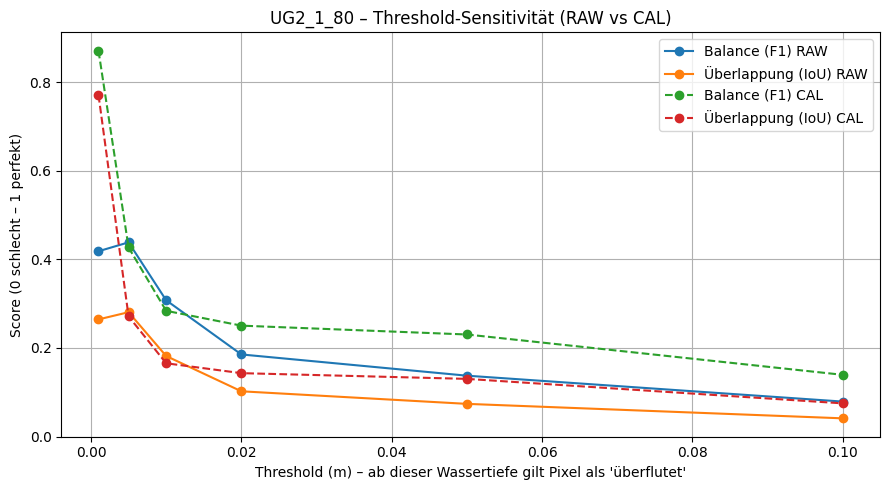

Threshold curve PNG: ug2/UG2_threshold_curve_raw_vs_cal.png


In [11]:
# Threshold sensitivity: shows how metrics depend on the treshold value
EVENT = "UG2_1_80"
MAX_DEPTH_M = 10.0
THRS = np.array([0.001,0.005,0.01,0.02,0.05,0.10], dtype="float32")

PNG_THR_CURVE = "ug2/UG2_threshold_curve_raw_vs_cal.png"
CSV_THR_CURVE = "ug2/ug2_threshold_curve_raw_vs_cal.csv"

# load event
ev = [e for e in events if e["name"] == EVENT][0]

# load pred/ref
pred_raw, ref, m, pred_prof, pred_nod = load_pred_ref_aligned(ev["pred"], ev["ref"])
pred_raw = pred_raw.copy(); pred_raw[~m] = np.nan
ref = ref.copy(); ref[~m] = np.nan

# fit calibrator and calculate it
cal_qm = fit_quantile_calibrator(ev["pred"], ev["ref"], max_depth_m=MAX_DEPTH_M, n_q=2000)
pred_cal = apply_quantile_calibrator(pred_raw, cal_qm)
pred_cal = pred_cal.copy(); pred_cal[~m] = np.nan

# calculate curves + CSV 
rows = []
PrecR, RecR, F1R, IoUR = [], [], [], []
PrecC, RecC, F1C, IoUC = [], [], [], []

for t in THRS:
    t = float(t)
    pr, rr, f1r, iour, *_ = metrics_counts(pred_raw, ref, m, t)
    pc, rc, f1c, iouc, *_ = metrics_counts(pred_cal, ref, m, t)

    PrecR.append(pr); RecR.append(rr); F1R.append(f1r); IoUR.append(iour)
    PrecC.append(pc); RecC.append(rc); F1C.append(f1c); IoUC.append(iouc)

    rows += [
        {"event": EVENT, "method":"RAW",    "thr_m":t, "Precision":pr, "Recall":rr, "F1":f1r, "IoU":iour},
        {"event": EVENT, "method":"CAL_QM", "thr_m":t, "Precision":pc, "Recall":rc, "F1":f1c, "IoU":iouc},
    ]

df_curve = pd.DataFrame(rows)
df_curve.to_csv(CSV_THR_CURVE, index=False)
print("Threshold curve CSV:", CSV_THR_CURVE)

# Plot (presentation)
plt.figure(figsize=(9,5))
plt.plot(THRS, F1R,  marker="o", label="Balance (F1) RAW")
plt.plot(THRS, IoUR, marker="o", label="Überlappung (IoU) RAW")
plt.plot(THRS, F1C,  marker="o", linestyle="--", label="Balance (F1) CAL")
plt.plot(THRS, IoUC, marker="o", linestyle="--", label="Überlappung (IoU) CAL")
plt.xlabel("Threshold (m) – ab dieser Wassertiefe gilt Pixel als 'überflutet'")
plt.ylabel("Score (0 schlecht – 1 perfekt)")
plt.title(f"{EVENT} – Threshold-Sensitivität (RAW vs CAL)")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(PNG_THR_CURVE, bbox_inches="tight", dpi=200)
plt.show()
print("Threshold curve PNG:", PNG_THR_CURVE)


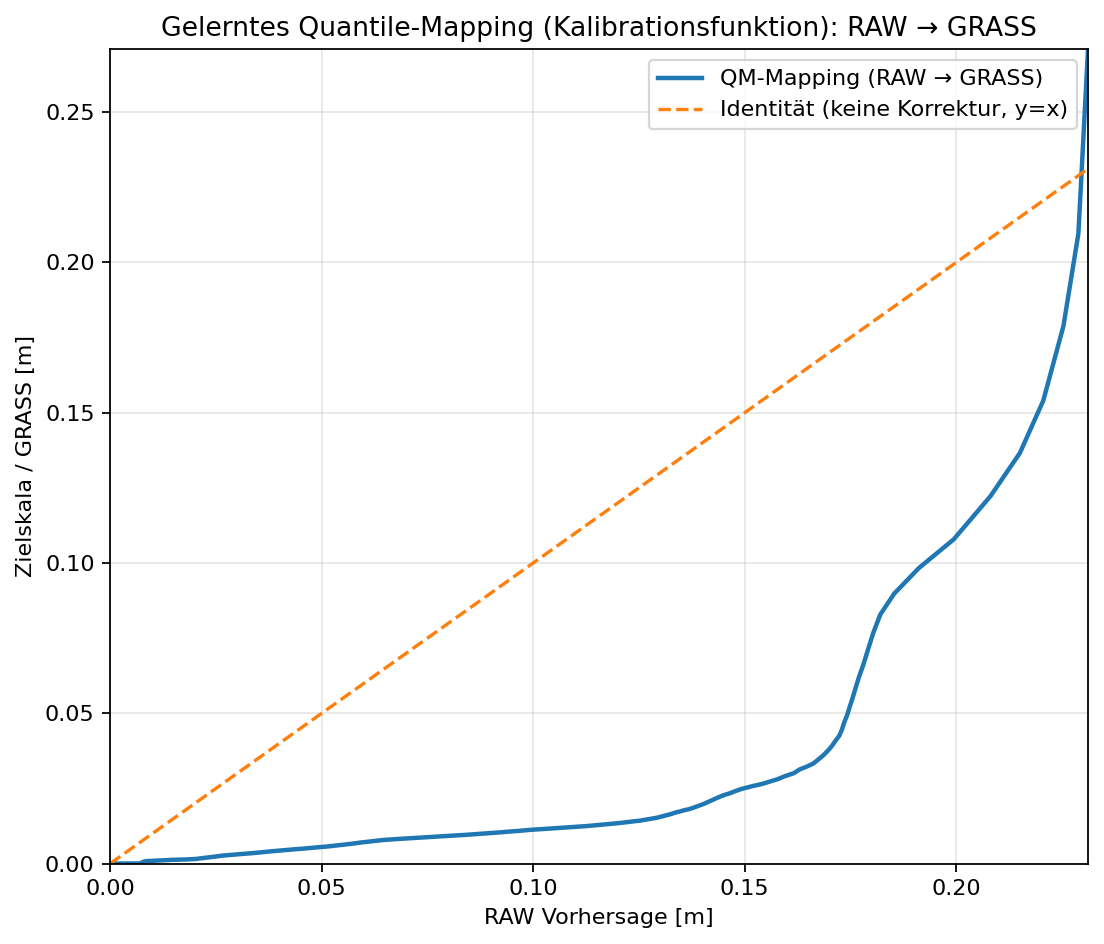

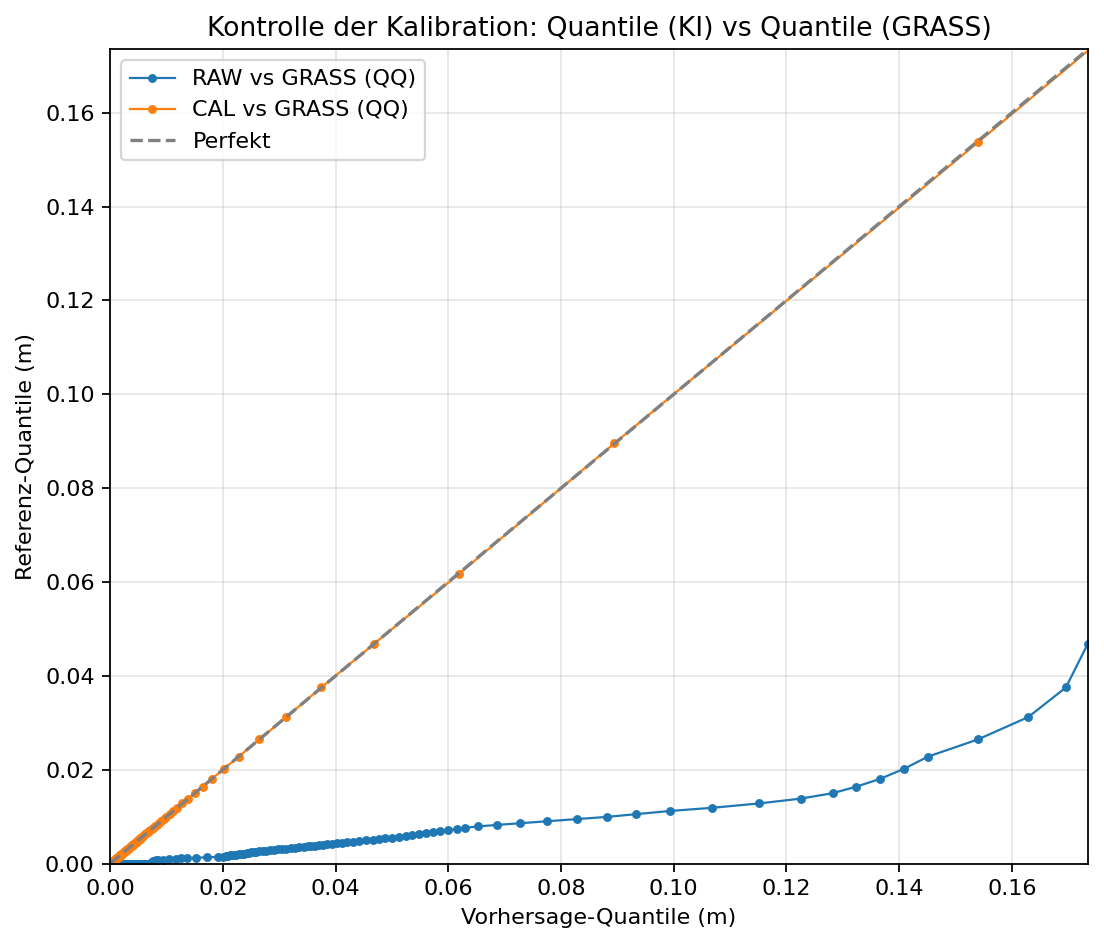

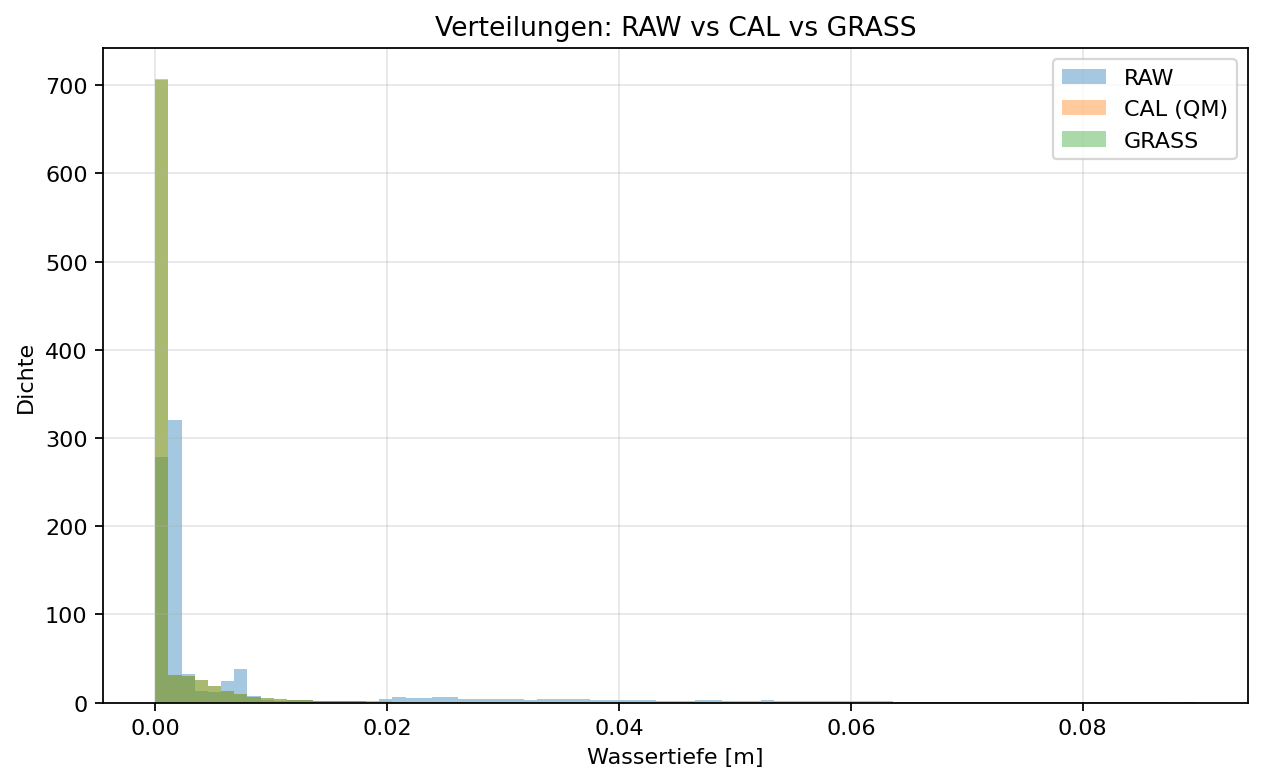

saved: ug2/QM_mapping_curve.png ug2/QM_qq_plot.png ug2/QM_distributions.png


In [12]:
# QM Mapping/QQ/Histogramm – plots for presentation

#settings
MAX_DEPTH_M = 10.0
N_SAMPLE = 200_000
N_Q = 2000
SEED = 42

OUT_MAP = "ug2/QM_mapping_curve.png"
OUT_QQ  = "ug2/QM_qq_plot.png"
OUT_HIST= "ug2/QM_distributions.png"

# sample possible values
x_all = pred_raw[m].astype("float32")
y_all = ref[m].astype("float32")

x_all = np.clip(x_all, 0, MAX_DEPTH_M)
y_all = np.clip(y_all, 0, MAX_DEPTH_M)

rng = np.random.default_rng(SEED)
if x_all.size > N_SAMPLE:
    idx = rng.choice(x_all.size, size=N_SAMPLE, replace=False)
    x = x_all[idx]
    y = y_all[idx]
else:
    x, y = x_all, y_all

# learn Quantile mapping (raw_q -> ref_q)
q = np.linspace(0, 1, N_Q, dtype="float64")
raw_q = np.quantile(x, q)
ref_q = np.quantile(y, q)

# remove double x-support points (Plateaus)
raw_unique, unique_idx = np.unique(raw_q, return_index=True)
ref_unique = ref_q[unique_idx]

# Function: apply QM
def qm_apply(arr):
    arr = np.clip(arr, 0, MAX_DEPTH_M)
    return np.interp(arr, raw_unique, ref_unique,
                     left=ref_unique[0], right=ref_unique[-1]).astype("float32")

x_cal = qm_apply(x)

# Plot: Mapping-Funktion
fig, ax = plt.subplots(figsize=(7, 6), dpi=160)

ax.plot(raw_unique, ref_unique, linewidth=2, label="QM-Mapping (RAW → GRASS)")
ax.plot([0, MAX_DEPTH_M], [0, MAX_DEPTH_M], linestyle="--", label="Identität (keine Korrektur, y=x)")

xlim = float(np.percentile(x, 99.9))
ylim = float(np.percentile(y, 99.9))
ax.set_xlim(0, xlim)
ax.set_ylim(0, ylim)

ax.set_xlabel("RAW Vorhersage [m]")
ax.set_ylabel("Zielskala / GRASS [m]")
ax.set_title("Gelerntes Quantile-Mapping (Kalibrationsfunktion): RAW → GRASS")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(OUT_MAP, bbox_inches="tight")  
plt.show()
plt.close(fig)

# Plot: QQ-Plot (Quantile-Quantile)
qq = np.linspace(0, 1, 400)
qx_raw = np.quantile(x, qq)
qx_cal = np.quantile(x_cal, qq)
qy_ref = np.quantile(y, qq)

fig, ax = plt.subplots(figsize=(7, 6), dpi=160)

ax.plot(qx_raw, qy_ref, marker="o", markersize=3, linewidth=1, label="RAW vs GRASS (QQ)")
ax.plot(qx_cal, qy_ref, marker="o", markersize=3, linewidth=1, label="CAL vs GRASS (QQ)")

lim = float(np.percentile(np.concatenate([qx_raw, qx_cal, qy_ref]), 99.5))
ax.plot([0, lim], [0, lim], linestyle="--", color="gray", label="Perfekt")

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

ax.set_xlabel("Vorhersage-Quantile (m)")
ax.set_ylabel("Referenz-Quantile (m)")
ax.set_title("Kontrolle der Kalibration: Quantile (KI) vs Quantile (GRASS)")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(OUT_QQ, bbox_inches="tight")
plt.show()
plt.close(fig)

# plot: Histogramm-Overlay
bins = np.linspace(0, np.percentile(y, 99.5), 80)

fig, ax = plt.subplots(figsize=(8, 5), dpi=160)

ax.hist(x,     bins=bins, density=True, alpha=0.4, label="RAW")
ax.hist(x_cal, bins=bins, density=True, alpha=0.4, label="CAL (QM)")
ax.hist(y,     bins=bins, density=True, alpha=0.4, label="GRASS")

ax.set_xlabel("Wassertiefe [m]")
ax.set_ylabel("Dichte")
ax.set_title("Verteilungen: RAW vs CAL vs GRASS")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(OUT_HIST, bbox_inches="tight")
plt.show()
plt.close(fig)

print("saved:", OUT_MAP, OUT_QQ, OUT_HIST)


In [13]:
# Infos about the AI-Model

model = tf.keras.models.load_model("models/final_unet_model_1_80.keras", compile=False)
model.summary()

# U-Net-indizes: Skip-Connections + Upsampling
has_concat = any(isinstance(l, tf.keras.layers.Concatenate) for l in model.layers)
has_upsamp = any(isinstance(l, (tf.keras.layers.UpSampling2D, tf.keras.layers.Conv2DTranspose)) for l in model.layers)

print("Concatenate (Skip-Connections):", has_concat)
print("Upsampling/TransposeConv:", has_upsamp)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 4) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      1,184 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_4[0][0]  

 Total params: 233,185 (910.88 KB)

 Trainable params: 232,545 (908.38 KB)

 Non-trainable params: 640 (2.50 KB)

Concatenate (Skip-Connections): True
Upsampling/TransposeConv: True
